# Trigonometric Functions — Lecture 2
## Complete Understanding of Trigonometric Functions

**Source:** [Trigonometric Functions 02 | Complete Understanding of Trigonometric Functions](https://www.youtube.com/watch?v=Gz-a-c1dt9I), Physics Wallah (Class 11 / IIT JEE), about 54 min

**Prerequisite:** Lecture 1 (angles, degree/radian, the six ratios, identities). This lecture uses all of it.

### What this lecture covers
1. Two warm-up questions on the Class 10 identities
2. **Basic** vs. **derived** trigonometric functions
3. From *ratio* (simple geometry) to *function* (coordinate geometry): the four quadrants
4. **Sign of $\sin x$** in each quadrant, with examples ($\sin 45^\circ$, $\sin 190^\circ$, $\sin 740^\circ$, $\sin(-200^\circ)$)
5. **Domain and range of $\sin x$**: $\mathbb{R}$ and $[-1, 1]$
6. **Sign, domain and range of $\cos x$**
7. Signs of $\sec, \csc, \tan, \cot$, which follow from $\sin$ and $\cos$
8. The **quadrant sign scheme** (which functions are positive where)
9. Homework: domain and range of $\tan x$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, Circle, FancyArrowPatch, Polygon, Rectangle

# Same look as Lecture 1
BLUE, ORANGE, AQUA, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
POS_BG, NEG_BG = "#2a78d61a", "#eb68341a"          # light tints for + / − regions
plt.rcParams.update({
    "figure.dpi": 110, "axes.edgecolor": INK2, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

def clean(ax, lim=1.4):
    ax.set_aspect("equal"); ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.axis("off")

def axes_cross(ax, lim=1.3):
    # Draw x and y axes through the origin
    for xy in [((-lim, 0), (lim, 0)), ((0, -lim), (0, lim))]:
        ax.annotate("", xy=xy[1], xytext=xy[0], arrowprops=dict(arrowstyle="-|>", color=INK2, lw=1))
    ax.text(lim, -0.08, "x", ha="right", va="top", color=INK2); ax.text(0.05, lim, "y", va="top", color=INK2)

def sweep(ax, start_deg, end_deg, r0=0.3, color=BLUE, turns_gap=0.12):
    # Arrowed sweep from start to end; spirals outward when |angle| > 360°
    t = np.linspace(np.deg2rad(start_deg), np.deg2rad(end_deg), 400)
    rr = r0 + turns_gap*np.abs(t - t[0])/(2*np.pi)
    ax.plot(rr*np.cos(t), rr*np.sin(t), color=color, lw=1.8)
    ax.add_patch(FancyArrowPatch((rr[-6]*np.cos(t[-6]), rr[-6]*np.sin(t[-6])),
                                 (rr[-1]*np.cos(t[-1]), rr[-1]*np.sin(t[-1])),
                                 arrowstyle="-|>", mutation_scale=12, color=color, lw=0))

def quadrant(deg):
    # Quadrant (1–4) of an angle's terminal side; None if it lies on an axis
    d = deg % 360
    if d % 90 == 0: return None
    return int(d // 90) + 1
print("ready")

ready


---
## 1. Warm-up Questions

### Q1. Prove that $\dfrac{\sin\theta - \cos\theta + 1}{\sin\theta + \cos\theta - 1} = \dfrac{1 + \sin\theta}{\cos\theta}$

This expression comes back in Class 12 **integration**, so it is worth remembering.

**Strategy.** Trigonometry has two "loving pairs" that work well together:
- $\sin\theta$ and $\cos\theta$
- $\sec\theta$ and $\tan\theta$, linked by $\sec^2\theta - \tan^2\theta = 1$

Here we switch from $\sin/\cos$ to $\sec/\tan$ by **dividing the numerator and denominator by $\cos\theta$**:

$$\text{LHS} = \frac{\tan\theta - 1 + \sec\theta}{\tan\theta + 1 - \sec\theta} = \frac{(\tan\theta + \sec\theta) - 1}{\tan\theta - \sec\theta + 1}$$

**Key trick:** replace the $1$ in the numerator by $\sec^2\theta - \tan^2\theta$, then factor it as $a^2 - b^2 = (a-b)(a+b)$:

$$(\tan\theta + \sec\theta) - (\sec^2\theta - \tan^2\theta) = (\tan\theta + \sec\theta) - (\sec\theta - \tan\theta)(\sec\theta + \tan\theta)$$
$$= (\tan\theta + \sec\theta)\,\big[1 - \sec\theta + \tan\theta\big]$$

The bracket is exactly the denominator $(\tan\theta - \sec\theta + 1)$, so it cancels:

$$\text{LHS} = \tan\theta + \sec\theta = \frac{\sin\theta}{\cos\theta} + \frac{1}{\cos\theta} = \frac{1 + \sin\theta}{\cos\theta} = \text{RHS} \quad\blacksquare$$

> Exam questions may instead ask you to prove $\text{LHS} = \sec\theta + \tan\theta$. It is the same result.

max |LHS − RHS| on (0°, 90°): 6.04e-14


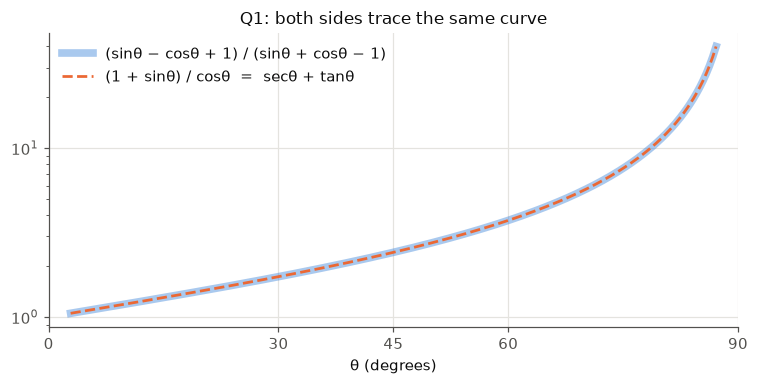

In [2]:
theta = np.linspace(0.05, np.pi/2 - 0.05, 400)
s, c = np.sin(theta), np.cos(theta)
lhs = (s - c + 1) / (s + c - 1)
rhs = (1 + s) / c
print(f"max |LHS − RHS| on (0°, 90°): {np.max(np.abs(lhs - rhs)):.2e}")

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(np.rad2deg(theta), lhs, color=BLUE, lw=5, alpha=0.4, label="(sinθ − cosθ + 1) / (sinθ + cosθ − 1)")
ax.plot(np.rad2deg(theta), rhs, color=ORANGE, lw=1.8, ls="--", label="(1 + sinθ) / cosθ  =  secθ + tanθ")
ax.set_yscale("log"); ax.set_xlim(0, 90); ax.set_xticks([0, 30, 45, 60, 90]); ax.set_xlabel("θ (degrees)")
ax.legend(frameon=False, loc="upper left"); ax.set_title("Q1: both sides trace the same curve", fontsize=11)
plt.tight_layout(); plt.show()

### Q2. If $\sec\theta + \tan\theta = 3$, find $\cos\theta$.

Whenever $\sec$ and $\tan$ appear together, think of $\sec^2\theta - \tan^2\theta = 1$:

$$(\sec\theta - \tan\theta)(\sec\theta + \tan\theta) = 1 \;\Longrightarrow\; \sec\theta - \tan\theta = \frac{1}{3}$$

Add the two equations:
$$\begin{aligned}
\sec\theta + \tan\theta &= 3\\
\sec\theta - \tan\theta &= \tfrac13\\ \hline
2\sec\theta &= \tfrac{10}{3} \;\Rightarrow\; \sec\theta = \tfrac53
\end{aligned}$$

$$\boxed{\cos\theta = \frac{1}{\sec\theta} = \frac{3}{5}}$$

(Subtracting instead gives $\tan\theta = \tfrac43$, which is the familiar 3-4-5 triangle.)

In [3]:
cos_t = 3/5
theta0 = np.arccos(cos_t)
print(f"θ = {np.rad2deg(theta0):.4f}°")
print(f"secθ + tanθ = {1/np.cos(theta0) + np.tan(theta0):.6f}  (should be 3)")
print(f"secθ − tanθ = {1/np.cos(theta0) - np.tan(theta0):.6f}  (should be 1/3)")

θ = 53.1301°
secθ + tanθ = 3.000000  (should be 3)
secθ − tanθ = 0.333333  (should be 1/3)


---
## 2. The Family of Six: Basic vs. Derived Functions

| Type | Functions | Why |
|---|---|---|
| **Basic** trigonometric functions | $\sin x$, $\cos x$ | Every other function can be written using these two |
| **Derived** trigonometric functions | $\tan x,\ \cot x,\ \sec x,\ \csc x$ | Built from $\sin$ and $\cos$ |

$$\tan x = \frac{\sin x}{\cos x}, \quad \cot x = \frac{\cos x}{\sin x}, \quad \sec x = \frac{1}{\cos x}, \quad \csc x = \frac{1}{\sin x}$$

The lecturer's analogy: $\sin x$ is "papa", $\cos x$ is "mummy", and the other four are their children. Together the six make up the family called trigonometry. **Understand $\sin$ and $\cos$ completely and you understand all of trigonometry.**

---
## 3. From Ratio to Function: Using Coordinate Geometry

| Class 10 | Class 11 |
|---|---|
| $\sin\theta$ is a **ratio** from **simple geometry**: a right triangle on its own | $\sin x$ is a **function** from **coordinate geometry**: the triangle is drawn on the $x$-$y$ plane |
| Sides are lengths, so they are **always positive** | Sides are **signed coordinates**, so they can be **negative** |

### Setup
The $x$- and $y$-axes divide the plane into **four quadrants** (I, II, III, IV, going anticlockwise). Draw the angle $x$ from the positive $x$-axis (the initial line). Take a point $(a, b)$ on its terminal line and drop a perpendicular to the $x$-axis:

- **Base** $B = a$, the $x$-coordinate: **negative to the left** of the $y$-axis
- **Perpendicular** $P = b$, the $y$-coordinate: **negative below** the $x$-axis
- **Hypotenuse** $H = \sqrt{a^2 + b^2}$: **always positive**, because a square root is never negative

Since $H > 0$ always, the sign of each function comes only from the signs of $P$ and $B$.

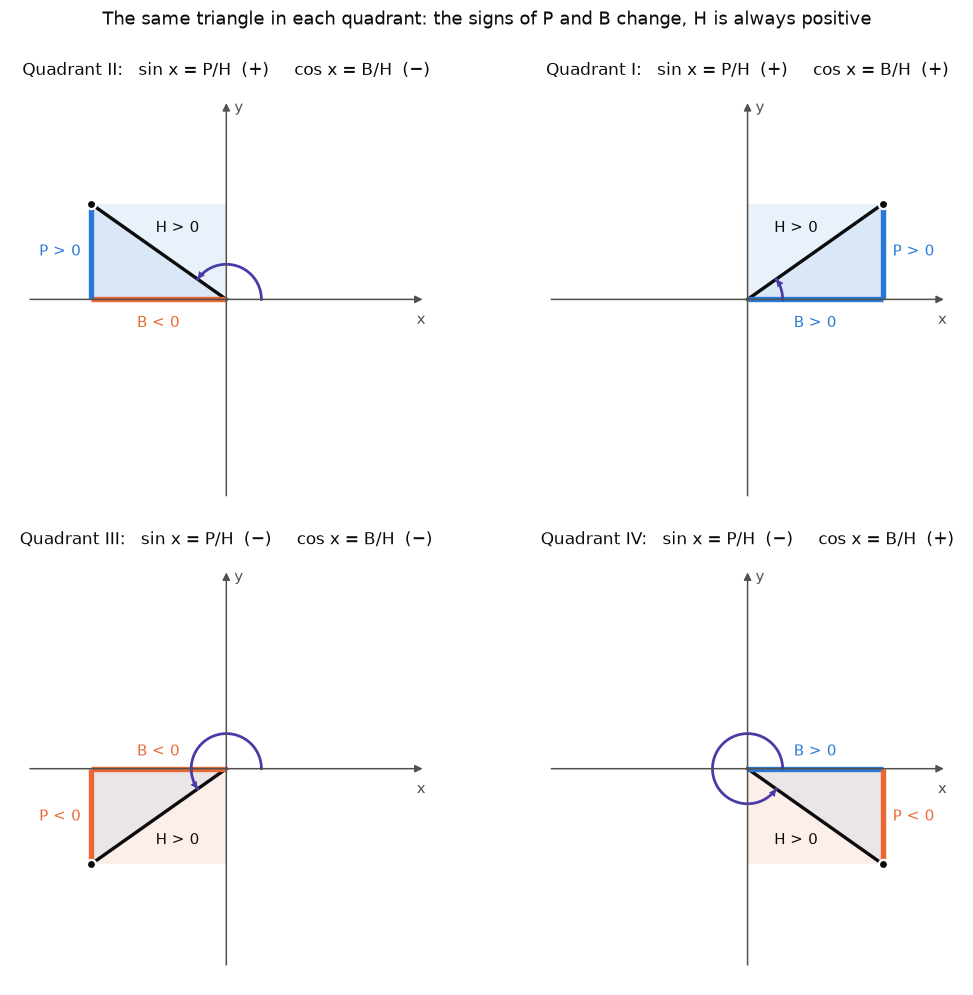

In [4]:
pts = {1: (0.85, 0.6), 2: (-0.85, 0.6), 3: (-0.85, -0.6), 4: (0.85, -0.6)}
names = {1: "I", 2: "II", 3: "III", 4: "IV"}

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
order = [2, 1, 3, 4]                                  # place panels where the quadrants sit
for ax, q in zip(axes.flat, order):
    clean(ax, 1.35); axes_cross(ax, 1.25)
    a, b = pts[q]
    ax.add_patch(Rectangle((min(0, a), min(0, b)), abs(a), abs(b), fc=POS_BG if b > 0 else NEG_BG, ec="none"))
    ax.add_patch(Polygon([(0, 0), (a, 0), (a, b)], closed=True, fc="#2a78d614", ec="none"))
    ax.plot([0, a], [0, b], color=INK, lw=2.2)                                 # H
    ax.plot([0, a], [0, 0], color=ORANGE if a < 0 else BLUE, lw=3.5, solid_capstyle="butt")   # B
    ax.plot([a, a], [0, b], color=ORANGE if b < 0 else BLUE, lw=3.5, solid_capstyle="butt")   # P
    ax.plot(a, b, "o", color=INK, ms=6, mec="white", mew=1.5, zorder=4)
    ang = np.rad2deg(np.arctan2(b, a)) % 360
    sweep(ax, 0, ang, r0=0.22, color=VIOLET, turns_gap=0)
    ax.text(a/2, -0.1 if b > 0 else 0.06, f"B {'< 0' if a < 0 else '> 0'}", ha="center",
            va="top" if b > 0 else "bottom", color=ORANGE if a < 0 else BLUE, fontsize=10)
    ax.text(a + (0.06 if a > 0 else -0.06), b/2, f"P {'< 0' if b < 0 else '> 0'}",
            ha="left" if a > 0 else "right", va="center", color=ORANGE if b < 0 else BLUE, fontsize=10)
    ax.text(a/2 - 0.12*np.sign(a), b/2 + 0.1*np.sign(b), "H > 0", ha="center",
            va="bottom" if b > 0 else "top", color=INK, fontsize=10)
    sin_sign = "+" if b > 0 else "−"; cos_sign = "+" if a > 0 else "−"
    ax.set_title(f"Quadrant {names[q]}:   sin x = P/H  ({sin_sign})     cos x = B/H  ({cos_sign})", fontsize=11)
fig.suptitle("The same triangle in each quadrant: the signs of P and B change, H is always positive",
             fontsize=12, y=1.0)
plt.tight_layout(); plt.show()

---
## 4. Complete Understanding of $\sin x$

### 4.1 Sign of $\sin x = \dfrac{P}{H}$

| Quadrant | $P$ | $H$ | $\sin x$ |
|---|---|---|---|
| I | $+$ | $+$ | **$+$** |
| II | $+$ | $+$ | **$+$** |
| III | $-$ | $+$ | **$-$** |
| IV | $-$ | $+$ | **$-$** |

$$\boxed{\sin x > 0 \text{ in quadrants I and II}, \qquad \sin x < 0 \text{ in quadrants III and IV}}$$

The sign of $\sin x$ depends only on **which quadrant the angle $x$ lies in**. In Class 10, $\sin\theta$ was always positive. As a function it can be **positive or negative**.

### 4.2 How to find the sign of $\sin(\text{any angle})$
1. Trace the angle from the initial line: **anticlockwise for positive**, **clockwise for negative**. Remove full turns of $360^\circ$.
2. See which quadrant the terminal line lands in.
3. Read the sign from the table.

| Angle | How it is traced | Quadrant | Sign of $\sin$ |
|---|---|---|---|
| $45^\circ$ | Directly | I | $+$ |
| $190^\circ$ | Just past $180^\circ$ | III | $-$ |
| $740^\circ$ | $2\times 360^\circ + 20^\circ$ (two full turns, then $20^\circ$) | I | $+$ |
| $-200^\circ$ | Clockwise: past $-180^\circ$ by $20^\circ$ | II | $+$ |

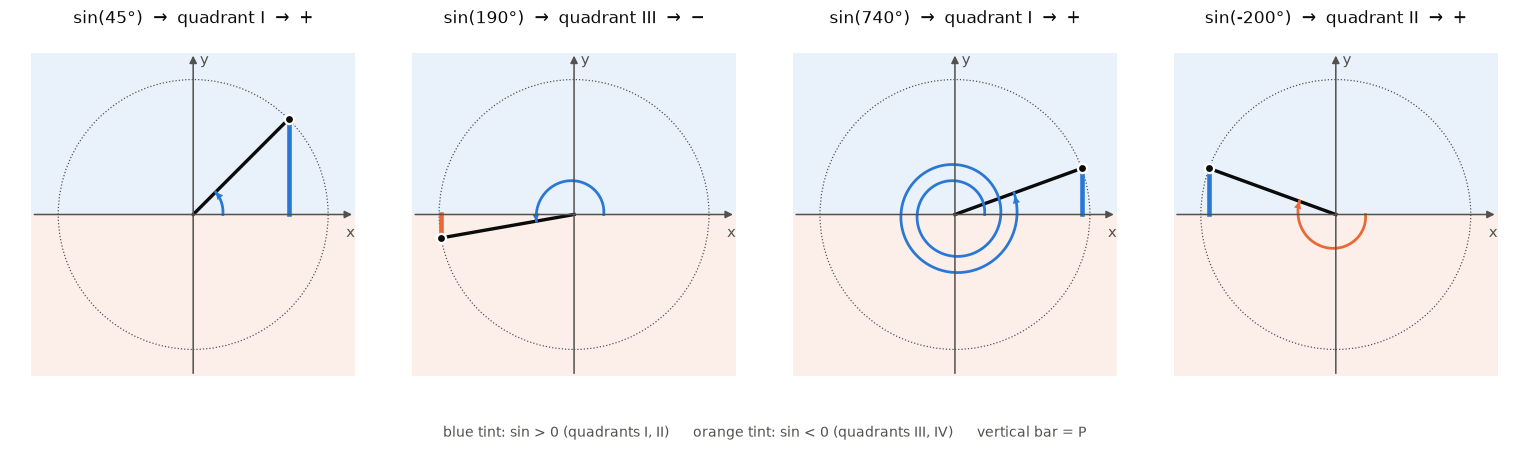

sin(  45°) = +0.7071
sin( 190°) = -0.1736
sin( 740°) = +0.3420
sin(-200°) = +0.3420


In [5]:
examples = [45, 190, 740, -200]
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, a in zip(axes, examples):
    clean(ax, 1.35); axes_cross(ax, 1.2)
    for q, (x0, y0) in {1: (0, 0), 2: (-1.2, 0), 3: (-1.2, -1.2), 4: (0, -1.2)}.items():
        ax.add_patch(Rectangle((x0, y0), 1.2, 1.2, fc=POS_BG if q in (1, 2) else NEG_BG, ec="none"))
    ax.add_patch(Circle((0, 0), 1, fill=False, ec=INK2, lw=0.8, ls=":"))
    r = np.deg2rad(a)
    ax.plot([0, np.cos(r)], [0, np.sin(r)], color=INK, lw=2.2)
    ax.plot(np.cos(r), np.sin(r), "o", color=INK, ms=6, mec="white", mew=1.5, zorder=4)
    ax.plot([np.cos(r)]*2, [0, np.sin(r)], color=BLUE if np.sin(r) > 0 else ORANGE, lw=3)
    sweep(ax, 0, a, r0=0.22, color=BLUE if a > 0 else ORANGE, turns_gap=0.12)
    q = quadrant(a); sgn = "+" if np.sin(r) > 0 else "−"
    ax.set_title(f"sin({a}°)  →  quadrant {['I','II','III','IV'][q-1]}  →  {sgn}", fontsize=11)
fig.text(0.5, 0.02, "blue tint: sin > 0 (quadrants I, II)      orange tint: sin < 0 (quadrants III, IV)      "
         "vertical bar = P", ha="center", color=INK2, fontsize=9)
plt.tight_layout(rect=(0, 0.05, 1, 1)); plt.show()

for a in examples:
    print(f"sin({a:>4}°) = {np.sin(np.deg2rad(a)):+.4f}")

### 4.3 Domain of $\sin x$ (the allowed inputs)
The **domain** is the set of all valid inputs. Lecture 1 showed that an angle can be **any real number**, and $\sin$ accepts every one of them ($0^\circ, 1^\circ, 2^\circ, \dots, -\pi, \dots$):

$$\boxed{\text{Domain of } \sin x = \mathbb{R} = (-\infty, \infty)}$$

### 4.4 Range of $\sin x$ (the possible outputs)
$\sin x = \dfrac{P}{H}$, where $P$ can be positive or negative. But in a right triangle the **hypotenuse is the largest side**, so $|P| \le H$:

- $|P| = H$ only when the triangle flattens completely. That happens as $x \to 90^\circ$, where $P \to H$ and the triangle's area becomes $0$.
- A fraction whose numerator is never larger than its denominator can **never exceed 1**.
- When $P$ is negative the value can go down to $-1$, but no lower.

$$\boxed{-1 \le \sin x \le 1, \qquad \text{Range of } \sin x = [-1, 1]}$$

So $\sin x = 2$, $\sin x = 1.1$ or $\sin x = -3$ are **impossible**. Values like $\tfrac12$, $\tfrac14$ or $-\tfrac12$ are fine.

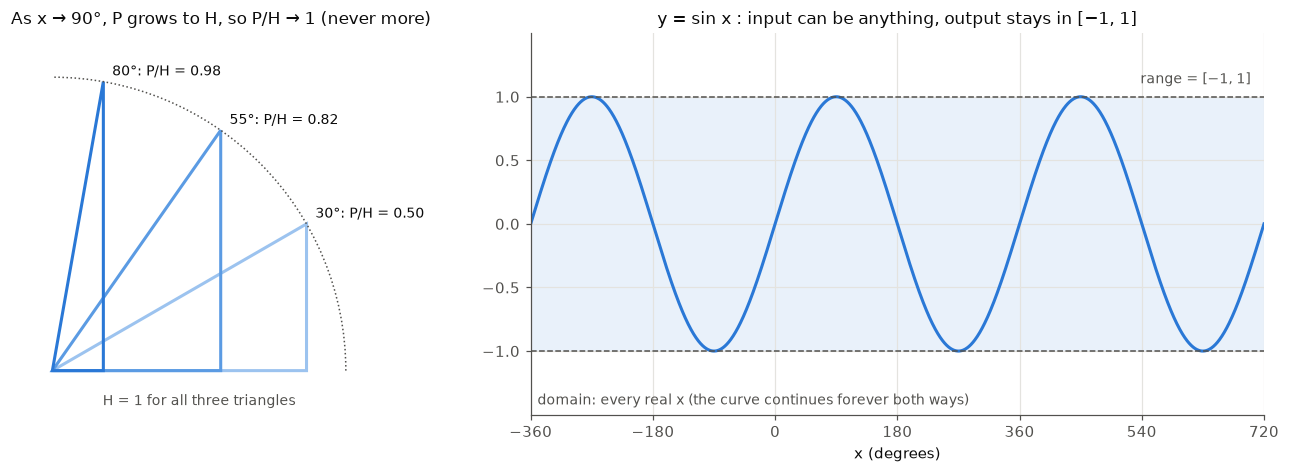

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), gridspec_kw={"width_ratios": [1, 1.6]})

# (a) as x → 90°, P → H
ax = axes[0]; ax.set_aspect("equal"); ax.axis("off"); ax.set_xlim(-0.1, 1.25); ax.set_ylim(-0.15, 1.15)
for deg, col in [(30, "#9cc3ef"), (55, "#5b9be3"), (80, BLUE)]:
    a = np.deg2rad(deg); x, y = np.cos(a), np.sin(a)
    ax.add_patch(Polygon([(0, 0), (x, 0), (x, y)], closed=True, fill=False, ec=col, lw=2))
    ax.text(x + 0.03, y + 0.01, f"{deg}°: P/H = {np.sin(a):.2f}", color=INK, fontsize=9, va="bottom")
ax.add_patch(Arc((0, 0), 2, 2, theta1=0, theta2=90, color=INK2, lw=1, ls=":"))
ax.text(0.5, -0.08, "H = 1 for all three triangles", ha="center", va="top", color=INK2, fontsize=9)
ax.set_title("As x → 90°, P grows to H, so P/H → 1 (never more)", fontsize=11)

# (b) sin over several turns stays inside [−1, 1]
ax = axes[1]
xd = np.linspace(-360, 720, 1500)
ax.axhspan(-1, 1, color=POS_BG, lw=0)
ax.plot(xd, np.sin(np.deg2rad(xd)), color=BLUE, lw=2)
ax.axhline(1, color=INK2, lw=1, ls="--"); ax.axhline(-1, color=INK2, lw=1, ls="--")
ax.set_xticks(range(-360, 721, 180)); ax.set_yticks([-1, -0.5, 0, 0.5, 1])
ax.set_xlim(-360, 720); ax.set_ylim(-1.5, 1.5); ax.set_xlabel("x (degrees)")
ax.text(700, 1.08, "range = [−1, 1]", ha="right", va="bottom", color=INK2, fontsize=9)
ax.text(-350, -1.42, "domain: every real x (the curve continues forever both ways)", color=INK2, fontsize=9)
ax.set_title("y = sin x : input can be anything, output stays in [−1, 1]", fontsize=11)
plt.tight_layout(); plt.show()

### Summary: "papa" $\sin x$

| Property | $\sin x$ |
|---|---|
| Positive in | Quadrants **I, II** |
| Negative in | Quadrants **III, IV** |
| Domain | $\mathbb{R}$ |
| Range | $[-1, 1]$ |

---
## 5. Complete Understanding of $\cos x$

### 5.1 Sign of $\cos x = \dfrac{B}{H}$
$H$ is always positive, so the sign comes from the base $B$ (the $x$-coordinate):

| Quadrant | $B$ | $\cos x$ |
|---|---|---|
| I | $+$ | **$+$** |
| II | $-$ | **$-$** |
| III | $-$ | **$-$** |
| IV | $+$ | **$+$** |

$$\boxed{\cos x > 0 \text{ in quadrants I and IV}, \qquad \cos x < 0 \text{ in quadrants II and III}}$$

The lecturer calls $\cos$ the "mummy function": it **starts positive** (I), sees the negative side of the world (II, III), and **ends positive** again (IV).

**Example:** $140^\circ$ lies in quadrant II, so $\sin 140^\circ > 0$ and $\cos 140^\circ < 0$.

### 5.2 Domain and range of $\cos x$
- **Domain:** $\mathbb{R}$, since any angle can be the input.
- **Range:** $[-1, 1]$, since $|B| \le H$ because the hypotenuse is the largest side. $\cos x = 1$ when $B = H$, which happens at $x = 0^\circ$. So $\cos x = 2$ is impossible.

| Property | $\sin x$ | $\cos x$ |
|---|---|---|
| Positive in | I, II | I, IV |
| Negative in | III, IV | II, III |
| Domain | $\mathbb{R}$ | $\mathbb{R}$ |
| Range | $[-1, 1]$ | $[-1, 1]$ |

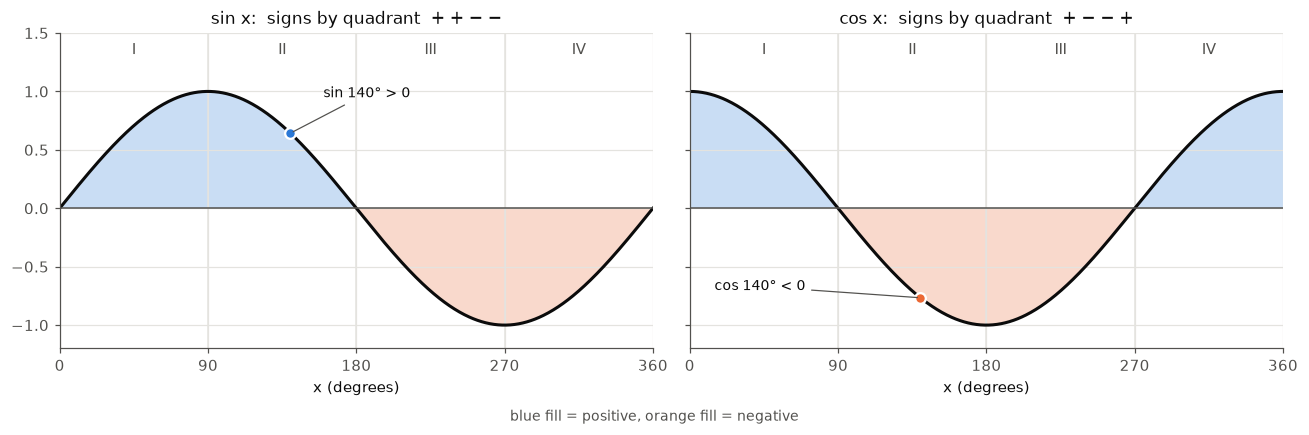

In [7]:
xd = np.linspace(0, 360, 721); r = np.deg2rad(xd)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, f, name in [(axes[0], np.sin, "sin x"), (axes[1], np.cos, "cos x")]:
    y = f(r)
    for q in range(4):
        ax.axvline(90*q, color=GRID, lw=1)
        ax.text(45 + 90*q, 1.32, ["I", "II", "III", "IV"][q], ha="center", color=INK2, fontsize=10)
    ax.fill_between(xd, 0, y, where=y >= 0, color=BLUE, alpha=0.25, lw=0)
    ax.fill_between(xd, 0, y, where=y < 0, color=ORANGE, alpha=0.25, lw=0)
    ax.plot(xd, y, color=INK, lw=2)
    ax.axhline(0, color=INK2, lw=1)
    ax.set_xticks(range(0, 361, 90)); ax.set_xlim(0, 360); ax.set_ylim(-1.2, 1.5); ax.set_xlabel("x (degrees)")
    signs = "+ + − −" if name == "sin x" else "+ − − +"
    ax.set_title(f"{name}:  signs by quadrant  {signs}", fontsize=11)
axes[0].plot(140, np.sin(np.deg2rad(140)), "o", color=BLUE, ms=7, mec="white", mew=1.5)
axes[0].annotate("sin 140° > 0", (140, np.sin(np.deg2rad(140))), xytext=(160, 0.95), fontsize=9, arrowprops=dict(arrowstyle="-", color=INK2, lw=0.8))
axes[1].plot(140, np.cos(np.deg2rad(140)), "o", color=ORANGE, ms=7, mec="white", mew=1.5)
axes[1].annotate("cos 140° < 0", (140, np.cos(np.deg2rad(140))), xytext=(15, -0.7), fontsize=9, arrowprops=dict(arrowstyle="-", color=INK2, lw=0.8))
fig.text(0.5, -0.02, "blue fill = positive, orange fill = negative", ha="center", color=INK2, fontsize=9)
plt.tight_layout(); plt.show()

---
## 6. Signs of the Derived Functions

The four "children" take their signs from $\sin$ and $\cos$.

**Reciprocals keep the sign.** The reciprocal of a positive number is positive and of a negative number is negative.
- $\sec x = \dfrac{1}{\cos x}$ has the **same sign as $\cos x$**: $+$ in I and IV, $-$ in II and III.
- $\csc x = \dfrac{1}{\sin x}$ has the **same sign as $\sin x$**: $+$ in I and II, $-$ in III and IV.

**Quotients:** $\tan x = \dfrac{\sin x}{\cos x}$, and $\cot x = \dfrac{1}{\tan x}$ has the same sign as $\tan$.

| Quadrant | $\sin$ | $\cos$ | $\tan = \sin/\cos$ |
|---|---|---|---|
| I | $+$ | $+$ | $+/+ = +$ |
| II | $+$ | $-$ | $+/- = -$ |
| III | $-$ | $-$ | $-/- = +$ |
| IV | $-$ | $+$ | $-/+ = -$ |

So $\tan$ and $\cot$ are $+$ in quadrants **I and III** and $-$ in **II and IV**.

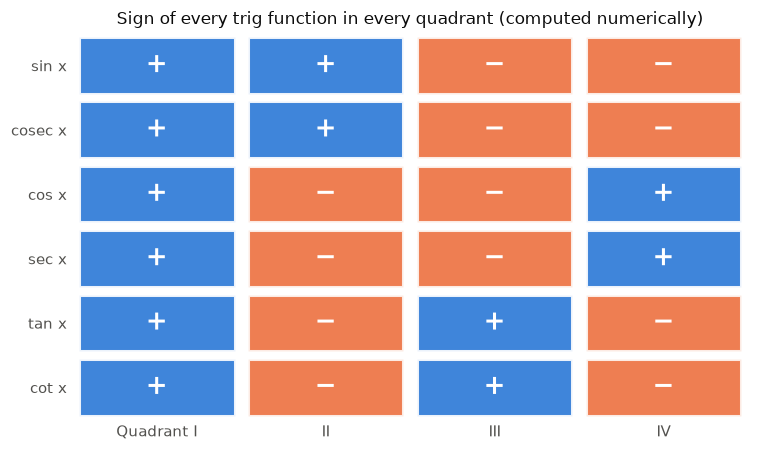

In [8]:
funcs = {
    "sin": np.sin, "cosec": lambda t: 1/np.sin(t),
    "cos": np.cos, "sec": lambda t: 1/np.cos(t),
    "tan": np.tan, "cot": lambda t: 1/np.tan(t),
}
mid = np.deg2rad([45, 135, 225, 315])                 # one test angle inside each quadrant
grid = np.array([[np.sign(f(mid[q])) for q in range(4)] for f in funcs.values()])

fig, ax = plt.subplots(figsize=(7, 4.2)); ax.grid(False)
for i in range(grid.shape[0]):
    for j in range(4):
        pos = grid[i, j] > 0
        ax.add_patch(Rectangle((j + 0.04, i + 0.06), 0.92, 0.88, fc=BLUE if pos else ORANGE,
                               alpha=0.9 if pos else 0.85, ec="white", lw=2))
        ax.text(j + 0.5, i + 0.5, "+" if pos else "−", ha="center", va="center", color="white",
                fontsize=17, fontweight="bold")
ax.set_xlim(0, 4); ax.set_ylim(grid.shape[0], 0)
ax.set_xticks(np.arange(4) + 0.5, ["Quadrant I", "II", "III", "IV"])
ax.set_yticks(np.arange(len(funcs)) + 0.5, [f"{k} x" for k in funcs])
ax.tick_params(length=0); [s.set_visible(False) for s in ax.spines.values()]
ax.set_title("Sign of every trig function in every quadrant (computed numerically)", fontsize=11)
plt.tight_layout(); plt.show()

---
## 7. The Quadrant Sign Scheme

$$\begin{array}{c|c}
\textbf{II: } \sin,\ \csc \text{ positive} & \textbf{I: All positive} \\ \hline
\textbf{III: } \tan,\ \cot \text{ positive} & \textbf{IV: } \cos,\ \sec \text{ positive}
\end{array}$$

- **Quadrant I:** all six functions are positive.
- **Quadrant II:** only $\sin$ and $\csc$ are positive.
- **Quadrant III:** only $\tan$ and $\cot$ are positive.
- **Quadrant IV:** only $\cos$ and $\sec$ are positive.

> A popular mnemonic (not from the lecture) is **"All Silver Tea Cups"** or **"Add Sugar To Coffee"**: going anticlockwise from quadrant I, the positive functions are **A**ll, **S**in, **T**an, **C**os.

The rest of trigonometry is built on this scheme, so it has to be memorised.

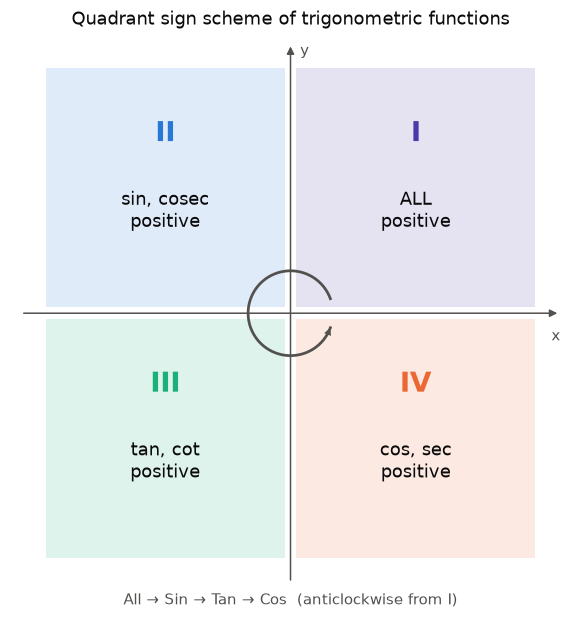

In [9]:
fig, ax = plt.subplots(figsize=(6.6, 6.6)); clean(ax, 1.45)
labels = {1: ("I", "ALL\npositive"), 2: ("II", "sin, cosec\npositive"),
          3: ("III", "tan, cot\npositive"), 4: ("IV", "cos, sec\npositive")}
colors = {1: VIOLET, 2: BLUE, 3: AQUA, 4: ORANGE}
corners = {1: (0, 0), 2: (-1.3, 0), 3: (-1.3, -1.3), 4: (0, -1.3)}
for q, (x0, y0) in corners.items():
    ax.add_patch(Rectangle((x0 + 0.03, y0 + 0.03), 1.24, 1.24, fc=colors[q], alpha=0.14, ec="none"))
    cx, cy = x0 + 0.65, y0 + 0.65
    ax.text(cx, cy + 0.28, labels[q][0], ha="center", va="center", fontsize=18, color=colors[q], fontweight="bold")
    ax.text(cx, cy - 0.12, labels[q][1], ha="center", va="center", fontsize=12, color=INK)
axes_cross(ax, 1.4)
sweep(ax, 20, 340, r0=0.22, color=INK2, turns_gap=0)
ax.text(0, -1.45, "All → Sin → Tan → Cos  (anticlockwise from I)", ha="center", va="top", color=INK2, fontsize=10)
ax.set_title("Quadrant sign scheme of trigonometric functions", fontsize=12)
plt.show()

### Practice: predict the sign, then check
Without a calculator, find the signs of
$\sin 300^\circ,\ \cos 300^\circ,\ \tan 300^\circ,\ \cos(-200^\circ),\ \tan 740^\circ,\ \sec 140^\circ,\ \csc 190^\circ,\ \cot(-30^\circ)$.

Run the next cell to check your answers.

In [10]:
def sign_report(name, deg):
    f = {"sin": np.sin, "cos": np.cos, "tan": np.tan,
         "sec": lambda t: 1/np.cos(t), "cosec": lambda t: 1/np.sin(t), "cot": lambda t: 1/np.tan(t)}[name]
    val = f(np.deg2rad(deg)); q = quadrant(deg)
    print(f"{name:>5}({deg:>5}°): quadrant {['I','II','III','IV'][q-1]:>3} → {'+' if val > 0 else '−'}   (value {val:+.4f})")

for name, deg in [("sin", 300), ("cos", 300), ("tan", 300), ("cos", -200),
                  ("tan", 740), ("sec", 140), ("cosec", 190), ("cot", -30)]:
    sign_report(name, deg)

  sin(  300°): quadrant  IV → −   (value -0.8660)
  cos(  300°): quadrant  IV → +   (value +0.5000)
  tan(  300°): quadrant  IV → −   (value -1.7321)
  cos( -200°): quadrant  II → −   (value -0.9397)
  tan(  740°): quadrant   I → +   (value +0.3640)
  sec(  140°): quadrant  II → −   (value -1.3054)
cosec(  190°): quadrant III → −   (value -5.7588)
  cot(  -30°): quadrant  IV → −   (value -1.7321)


---
## 8. Summary

| | $\sin x$ | $\cos x$ | $\tan x$ | $\cot x$ | $\sec x$ | $\csc x$ |
|---|---|---|---|---|---|---|
| Type | basic | basic | derived | derived | derived | derived |
| $+$ in quadrants | I, II | I, IV | I, III | I, III | I, IV | I, II |
| $-$ in quadrants | III, IV | II, III | II, IV | II, IV | II, III | III, IV |
| Domain | $\mathbb{R}$ | $\mathbb{R}$ | homework | next lecture | next lecture | next lecture |
| Range | $[-1,1]$ | $[-1,1]$ | homework | next lecture | next lecture | next lecture |

**Key ideas**
- Class 10 ratios come from simple geometry. Class 11 functions come from **coordinate geometry**, so $P$ and $B$ carry signs.
- $H = \sqrt{P^2 + B^2} > 0$ always.
- $|P| \le H$ and $|B| \le H$, which is why $\sin$ and $\cos$ stay in $[-1, 1]$.
- To find a sign: remove full turns, locate the quadrant, and read the scheme.

---
## 9. Homework (from the lecture)
> Find the **domain** and **range** of $f(x) = \tan x$, **with reasoning**. Try it yourself before opening the hint or running the next cell.

<details>
<summary>Hint / answer (open after attempting)</summary>

- $\tan x = \dfrac{\sin x}{\cos x}$ is undefined where $\cos x = 0$, that is at $x = \dfrac{\pi}{2} + n\pi$ ($90^\circ, 270^\circ, -90^\circ, \dots$). In the triangle picture, $B = 0$ there.
- **Domain:** $\mathbb{R} \setminus \left\{\dfrac{(2n+1)\pi}{2} : n \in \mathbb{Z}\right\}$
- $\tan x = P/B$ has no upper bound, because $P$ can be much larger than $B$ (as $B \to 0$, $\tan \to \pm\infty$). It also takes negative values in quadrants II and IV.
- **Range:** $\mathbb{R} = (-\infty, \infty)$
</details>

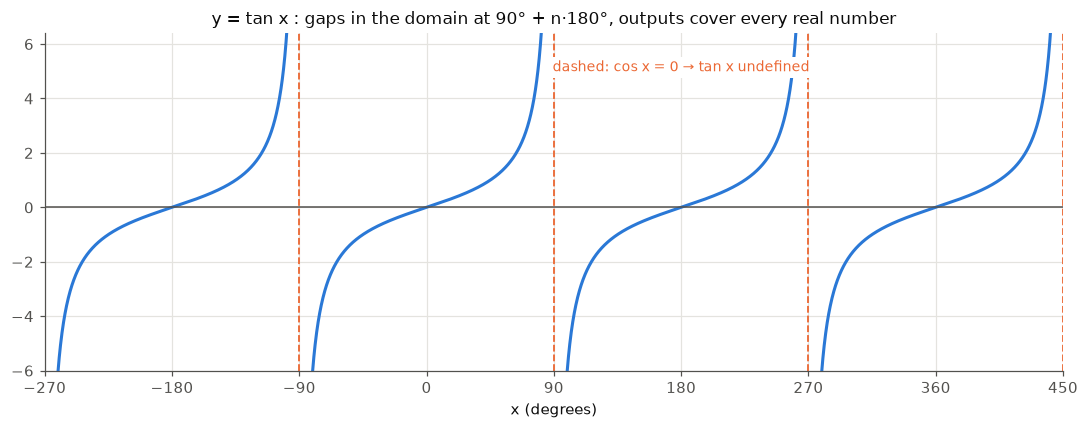

In [11]:
# Visual check for the homework: tan x blows up wherever cos x = 0
xd = np.linspace(-270, 450, 4000); r = np.deg2rad(xd)
y = np.tan(r); y[np.abs(np.cos(r)) < 0.01] = np.nan          # break the curve at the asymptotes

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(xd, y, color=BLUE, lw=2)
for k in range(-270, 451, 180):
    ax.axvline(k, color=ORANGE, lw=1.2, ls="--")
ax.text(180, 5.0, "dashed: cos x = 0 → tan x undefined", color=ORANGE, ha="center", fontsize=9,
        bbox=dict(fc="white", ec="none", pad=2))
ax.axhline(0, color=INK2, lw=1)
ax.set_ylim(-6, 6.4); ax.set_xlim(-270, 450); ax.set_xticks(range(-270, 451, 90)); ax.set_xlabel("x (degrees)")
ax.set_title("y = tan x : gaps in the domain at 90° + n·180°, outputs cover every real number", fontsize=11)
plt.tight_layout(); plt.show()